In [1]:
import torch, os, cv2, re
import scipy.io as sio
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

from PIL import Image, ImageDraw, ImageFont

import sys
sys.path.append('/home/jinhanz/cs/concreteness')  # Replace with the actual path to the parent directory
from other.utils import draw_highlighted_caption

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer
wnl = WordNetLemmatizer()
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

stimuli_root = "/opt/jinhanz/results/2509_concreteness/stimuli/"
results_root = "/opt/jinhanz/results/2509_concreteness/results/"

[nltk_data] Downloading package punkt to /home/jinhanz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/jinhanz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jinhanz/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [3]:
import json, random, csv, time, os, random
import numpy as np
from statistics import mean
from scipy.stats import ttest_rel, ttest_ind
import pandas as pd
from datetime import datetime
from tqdm import tqdm  # for progress bar
import matplotlib.pyplot as plt
from collections import defaultdict
import torchvision.transforms as T

# Load data
with open("../../data/coco_caption_concereteness_with_lemmatization.json") as f:
    data = json.load(f)

for i, img in enumerate(data):
    max_score, min_score = 0, 100
    max_id, min_id = 0, 0
    for c, cap in enumerate(img['caption_concreteness']):
        mean_score = mean(cap['concreteness'])
        data[i]['caption_concreteness'][c]['concrete_score'] = mean_score
        data[i]['caption_concreteness'][c]['abstract_score'] = mean_score
        if mean_score > max_score:
            max_score = mean_score
            max_id = cap['id']
        if mean_score < min_score:
            min_score = mean_score
            min_id = cap['id']
    data[i]['concrete_abstact_diff'] = {
        'value' : max_score - min_score,
        'ids': [max_id, min_id],
}

all_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var", "abstract_score", "concrete_score"]
test_attributes = ["matching_score", "word_importances", "char_number", "word_number", "word_frequency", "emap_var"]

# Filter entries with both concrete and abstract ids
filtered_data = [item for item in data if len(set(item['concrete_abstact_diff']['ids'])) > 1]
filtered_data = sorted(filtered_data, key=lambda x: x['concrete_abstact_diff']['value'], reverse=True)

def extract_attr_lists(data_subset):
    ids = []
    abs_captions = []
    con_captions = []
    value_diffs = []
    abs_vals = {attr: [] for attr in all_attributes}
    con_vals = {attr: [] for attr in all_attributes}

    for entry in data_subset:
        ids.append(entry['image'])
        value_diffs.append(entry['concrete_abstact_diff']['value'])
        con_id, abs_id = entry['concrete_abstact_diff']['ids']
        con_cap = next(c for c in entry['caption_concreteness'] if c['id'] == con_id)
        abs_cap = next(c for c in entry['caption_concreteness'] if c['id'] == abs_id)

        abs_captions.append(abs_cap)
        con_captions.append(con_cap)

        for attr in ["concrete_score", "abstract_score"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        if 'char_number' in all_attributes:
            abs_vals['char_number'].append(len(abs_cap['caption']))
            con_vals['char_number'].append(len(con_cap['caption']))

        if 'word_number' in all_attributes:
            abs_vals['word_number'].append(len(abs_cap['caption'].split(' ')))
            con_vals['word_number'].append(len(con_cap['caption'].split(' ')))

        for attr in ["matching_score", "emap_var"]:
            if attr in all_attributes:
                abs_vals[attr].append(abs_cap[attr])
                con_vals[attr].append(con_cap[attr])

        for attr in ["word_importances", "word_frequency"]:
            if attr in all_attributes:
                abs_vals[attr].append(mean(abs_cap[attr]))
                con_vals[attr].append(mean(con_cap[attr]))

    return ids, value_diffs, abs_captions, con_captions, abs_vals, con_vals

ids_all, value_diffs_all, _, _, abs_vals_all, con_vals_all = extract_attr_lists(filtered_data)

experiment = '20250723_193742'

selected_indices = []
saved = pd.read_csv(f"{stimuli_root}/250602-250723_stimuli_average/{experiment}/captions_and_attributes.csv")
saved_ids = saved['image_id'].tolist()
for e, entry in enumerate(filtered_data):
    if entry['image'] in saved_ids:
        selected_indices.append(e)

selected_indices.sort()
selected_entries = [filtered_data[idx] for idx in selected_indices]

ids_selected, value_diffs_selected, abs_captions_selected, con_captions_selected, abs_vals_selected, con_vals_selected = extract_attr_lists(selected_entries)

In [10]:
analysis_name = "251104_lextale60"
data_all = pd.DataFrame()

### Word Importance Vector Generation

In [11]:
def normalized_ranking(raw_importance):
    ranks = np.argsort(np.argsort(raw_importance)) + 1  # +1 to make ranks start from 1
    # normalized_ranks = ranks
    # normalized_ranks = ranks / sum(ranks)
    normalized_ranks = (ranks - ranks.min()) / (ranks.max() - ranks.min())
    return normalized_ranks

In [12]:
normalized_ranking([0.1, 0.2, 0.3])

array([0. , 0.5, 1. ])

In [13]:
for idx, (image_id, abs_cap, con_cap) in enumerate(zip(ids_selected, abs_captions_selected, con_captions_selected)):
    # Load image
    img_path = f"{results_root}/{analysis_name}/human/image/images/matched_abs_{image_id.split('/')[-1]}"

    abs_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{abs_cap['id']}.pt", map_location="cpu")
    con_emap = torch.load(f"../../data/emaps_resized/{image_id.split('_')[-1].split('.')[0]}_{con_cap['id']}.pt", map_location="cpu")

    img = Image.open(img_path).convert("RGB")
    h, w = img.size
    resize = T.Resize((w,h))

    emaps =resize(torch.stack([abs_emap, con_emap], dim=0))

    abs_emap = emaps[0].numpy()
    con_emap = emaps[1].numpy()

    for con, cap, map in zip(['abs', 'con'], [abs_cap, con_cap], [abs_emap, con_emap]):
        human_map = torch.load(f"{results_root}/{analysis_name}/human/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        grp1_map = torch.load(f"{results_root}/{analysis_name}/grp1/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()
        grp2_map = torch.load(f"{results_root}/{analysis_name}/grp2/image/pts/matched_{con}_{image_id.split('/')[-1].split('.')[0]}_GSmo_41.pt", map_location="cpu").numpy()

        data_all = pd.concat([data_all, pd.DataFrame([{
            "condition": con,
            "image_id": image_id,
            "caption": cap['caption'],
            "caption_words": [re.sub(r'[^\w\s]', '', tok) for tok in cap['caption'].split()],
            "concreteness": cap["concreteness"],
            "concrete_score": mean(cap['concreteness']),
            "target_words": cap["words"],
            "clip_map": map,
            "human_map": human_map,
            "grp1_map": grp1_map,
            "grp2_map": grp2_map,
            "clip_word_importance": normalized_ranking(cap['word_importances']),
            "human_word_importance": None,
            "grp1_word_importance": None,
            "grp2_word_importance": None,
        }], index=[f"matched_{con}_{image_id.split('/')[-1]}"])], ignore_index=False)

In [14]:
import ast 

image_info_segmentation = pd.read_csv(f"{stimuli_root}/250619-250723_stimuli_experiment/20250723_193742/image_info_segmentation.csv")

for _, row in image_info_segmentation.iterrows():
    trial_id = row['trial_id']

    if "mismatched" in trial_id:
        continue  

    word_spans = ast.literal_eval(row['word_spans'])

    for group in ['human', 'grp1', 'grp2']:  

        fixations = pd.read_excel(f"{results_root}/{analysis_name}/{group}/whole_screen/fixations/{trial_id}.xlsx")

        num_fixations = []

        for span in word_spans:
            x1, x2, y1, y2 = span

            # Filter fixations within the bounding box
            y1 = 1024 - y1
            y2 = 1024 - y2
            y1, y2 = y2, y1

            num_fixs = np.sum((fixations['CURRENT_FIX_X'] >= x1) & (fixations['CURRENT_FIX_X'] <= x2) &
                            (fixations['CURRENT_FIX_Y'] >= y1) & (fixations['CURRENT_FIX_Y'] <= y2))
            
            num_fixations.append(num_fixs)

        # Min-max normalization for num_fixations
        # data_all.at[trial_id, f'{group}_word_importance'] = (np.array(num_fixations) - np.min(num_fixations)) / (np.max(num_fixations) - np.min(num_fixations))
        data_all.at[trial_id, f'{group}_word_importance'] = normalized_ranking(np.array(num_fixations))

#### Visualize Word Importance

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import font_manager

for group in ['human', 'grp1', 'grp2']:

    # output_dir = f'{results_root}/{analysis_name}/{group}/caption/word_importance'
    output_dir = f'{results_root}/251204_normalized_ranking/{group}/caption/word_importance'
    os.makedirs(output_dir, exist_ok=True)

    for trial_id, info in data_all.iterrows():
        # Abstract caption
        draw_highlighted_caption(info['caption'],
                                info['target_words'],
                                info['concreteness'],
                                info[f'{group}_word_importance'],
                            save_path=os.path.join(output_dir, trial_id+".png"))

### Calculate PCC (Alignment Scores)

In [15]:
for group in ['human', 'grp1', 'grp2']:
    for trial_id, info in data_all.iterrows():
        data_all.at[trial_id, f'{group}_map_pcc'] = np.corrcoef(info['clip_map'].flatten(), info[f'{group}_map'].flatten())[0, 1]
        # only words with concreteness ratings
        data_all.at[trial_id, f'{group}_word_importance_pcc'] = np.corrcoef(info['clip_word_importance'], info[f'{group}_word_importance'])[0, 1]
        data_all.at[trial_id, f'{group}_concatenate_pcc'] = np.corrcoef(
            np.concatenate([info['clip_map'].flatten(), info['clip_word_importance']]),
            np.concatenate([info[f'{group}_map'].flatten(), info[f'{group}_word_importance']])
        )[0, 1]

## Statistical Analysis

### Alignment difference between conditions

Paired t test (by image item) comparing CLIP-human alignment in concrete vs abstract conditions

In [16]:
# T-test analysis
for group in ['human', 'grp1', 'grp2']:
    print(f"Group: {group}")
    for measurement in [f'{group}_map_pcc', f'{group}_word_importance_pcc', f'{group}_concatenate_pcc']:
        con_pcc_scores = [info[measurement] for trial_id, info in data_all.iterrows() if info['condition'] == 'con']
        abs_pcc_scores = [info[measurement] for trial_id, info in data_all.iterrows() if info['condition'] == 'abs']

        # Perform t-test
        t_stat, p_value = ttest_rel(con_pcc_scores, abs_pcc_scores)

        print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

Group: human
(human_map_pcc) T-statistic: -0.29234174075842534, P-value: 0.7707917492811607
(human_word_importance_pcc) T-statistic: 0.7071639612064731, P-value: 0.481545431694793
(human_concatenate_pcc) T-statistic: -0.29229078235978573, P-value: 0.7708305644814427
Group: grp1
(grp1_map_pcc) T-statistic: -0.34453442443020527, P-value: 0.7313599134451229
(grp1_word_importance_pcc) T-statistic: 0.5413811939498916, P-value: 0.5897683867438808
(grp1_concatenate_pcc) T-statistic: -0.34463261397164036, P-value: 0.7312863705670571
Group: grp2
(grp2_map_pcc) T-statistic: -0.3818574778673187, P-value: 0.7035923133317876
(grp2_word_importance_pcc) T-statistic: 1.2083131573251729, P-value: 0.23053135652718917
(grp2_concatenate_pcc) T-statistic: -0.38146042006538067, P-value: 0.7038856849860804


Regression analysis (if caption concreteness predicts CLIP-human alignment)

In [17]:
def linreg_scatter(plot_data, x_attr, y_attr, condition_attr=None, title=None, xlabel=None, ylabel=None, save_path=None):
    plt.figure(figsize=(8, 6))
    slope, intercept, r_value, p_value, std_err = linregress(plot_data[x_attr], plot_data[y_attr])
    print(f"Slope: {slope:.4f}, Intercept: {intercept:.4f}, R^2: {r_value**2:.4f}, p-value: {p_value:.4e}")
    sns.scatterplot(data=plot_data, x=x_attr, y=y_attr, hue=condition_attr, palette={'con': 'tab:blue', 'abs': 'tab:orange'}, alpha=0.7, edgecolor='k')
    sns.regplot(data=plot_data, x=x_attr, y=y_attr, scatter=False, color='red')
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Condition')
    plt.show()

Slope: -0.1043, Intercept: 0.7386, R^2: 0.0047, p-value: 5.4385e-01


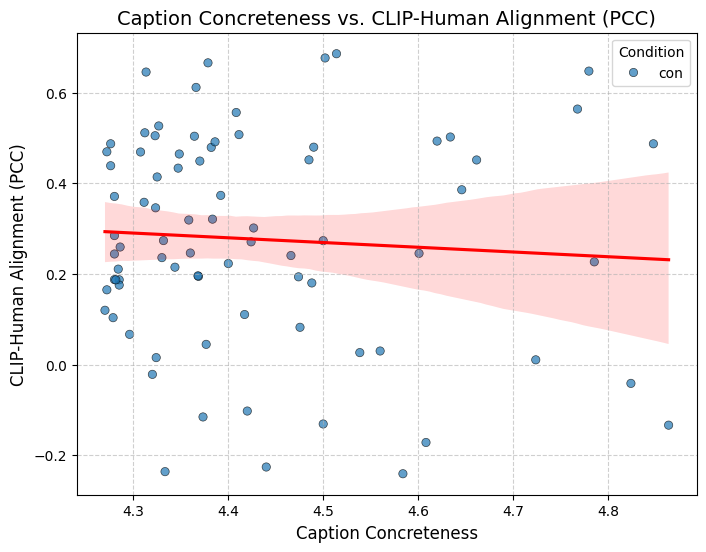

In [18]:
# Extract concreteness scores and PCC values
concreteness_scores = [info['concrete_score'] for trial_id, info in data_all.iterrows()]
human_clip_pcc = [info['human_map_pcc'] for trial_id, info in data_all.iterrows()]
conditions = [info['condition'] for trial_id, info in data_all.iterrows()]  # 'con' or 'abs'

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Concreteness': concreteness_scores,
    'PCC': human_clip_pcc,
    'Condition': conditions
})

plot_data = plot_data[plot_data["Condition"]=="con"]

linreg_scatter(plot_data,
                 x_attr='Concreteness',
                 y_attr='PCC',
                 condition_attr='Condition',
                 title='Caption Concreteness vs. CLIP-Human Alignment (PCC)',
                 xlabel='Caption Concreteness',
                 ylabel='CLIP-Human Alignment (PCC)',
                 save_path=None)


### Per EMHMM Group Analysis

In [19]:
# T-test analysis
for measurement in [f'map_pcc', f'word_importance_pcc', f'concatenate_pcc']:

    # Perform t-test
    t_stat, p_value = ttest_rel(data_all[f'grp1_{measurement}'], data_all[f'grp2_{measurement}'])

    print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

(map_pcc) T-statistic: 8.882123821026486, P-value: 1.329872587405734e-15
(word_importance_pcc) T-statistic: 2.737430137647209, P-value: 0.006897764164352879
(concatenate_pcc) T-statistic: 8.877405963544996, P-value: 1.3681111004647022e-15


mixed-effect model

In [20]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for trial_id, info in data_all.iterrows():
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": trial_id,
            "condition": info["condition"],
            "group": "grp1",
            "map_pcc": info["grp1_map_pcc"],
            "word_importance_pcc": info["grp1_word_importance_pcc"],
            "concatenate_pcc": info["grp1_concatenate_pcc"]
        }, {
            "trial_id": trial_id,
            "condition": info["condition"],
            "group": "grp2",
            "map_pcc": info["grp2_map_pcc"],
            "word_importance_pcc": info["grp2_word_importance_pcc"],
            "concatenate_pcc": info["grp2_concatenate_pcc"]
        }])
    ], ignore_index=True)

# Display the prepared long format DataFrame
long_format_data

,trial_id,condition,group,map_pcc,word_importance_pcc,concatenate_pcc
0,matched_abs_COCO_val2014_000000057495.jpg,abs,grp1,0.221606,0.236364,0.221797
1,matched_abs_COCO_val2014_000000057495.jpg,abs,grp2,0.069581,0.309091,0.070045
2,matched_con_COCO_val2014_000000057495.jpg,con,grp1,0.120399,-0.218182,0.120657
3,matched_con_COCO_val2014_000000057495.jpg,con,grp2,0.021252,-0.145455,0.021581
4,matched_abs_COCO_val2014_000000314426.jpg,abs,grp1,0.575622,0.503030,0.575689
...,...,...,...,...,...,...
315,matched_con_COCO_val2014_000000320743.jpg,con,grp2,0.067415,0.406061,0.068022
316,matched_abs_COCO_val2014_000000098658.jpg,abs,grp1,0.281409,0.700000,0.281525
317,matched_abs_COCO_val2014_000000098658.jpg,abs,grp2,0.072988,0.833333,0.073187
318,matched_con_COCO_val2014_000000098658.jpg,con,grp1,0.194710,0.559441,0.194952


In [21]:
import pandas as pd
import statsmodels.formula.api as smf

for measurement in ['map_pcc', 'word_importance_pcc', 'concatenate_pcc']:
    print(f"Mixed-Effect Model Analysis for {measurement}:")
    model = smf.mixedlm(f"{measurement} ~ group * condition", long_format_data, groups="trial_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for map_pcc:
                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       map_pcc 
No. Observations:        320           Method:                   REML    
No. Groups:              160           Scale:                    0.0023  
Min. group size:         2             Log-Likelihood:           202.9625
Max. group size:         2             Converged:                Yes     
Mean group size:         2.0                                             
-------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                       0.287    0.026 11.130 0.000  0.237  0.338
group[T.grp2]                  -0.047    0.008 -6.202 0.000 -0.061 -0.032
condition[T.con]               -0.008    0.036 -0.212 0.832 -0.079  0.064
group[T.grp2]:c

#### Interpreting EMHMM Groups
Exploring more fixations on the image?

In [ ]:
for trial_id, info in data_all.iterrows():
    
    # number of fixations on image; for confirming interpretations on EMHMM group
    # explorting strategy -> more fixations?
    for group in ['grp1', 'grp2']:
        fixations = pd.read_excel(f"{results_root}/{analysis_name}/{group}/image/fixations/{trial_id}.xlsx")
        data_all.at[trial_id, f'{group}_emap_var'] = np.var(info[f'{group}_map'])
        data_all.at[trial_id, f'{group}_image_fixations_num'] = len(fixations)

In [39]:
for measurement in ['emap_var', 'image_fixations_num']:

    t_stat, p_value = ttest_rel(data_all[f'grp1_{measurement}'], data_all[f'grp2_{measurement}'])

    print(f"({measurement}) T-statistic: {t_stat}, P-value: {p_value}")

(emap_var) T-statistic: 7.937610245167455, P-value: 3.488339337842698e-13
(image_fixations_num) T-statistic: 45.4024732188378, P-value: 6.1166662653967184e-93


### Attribute-WordImportance Correlation

#### Concreteness vs Word Importance

In [22]:
all_words_df = pd.DataFrame(columns=[
                "trial_id",
                "word_index",
                "word",
                "pos_tag",
                "condition",
                "concreteness",
                "clip_importance",
                "human_importance",
                "grp1_importance",
                "grp2_importance",
            ])

for trial_id, info in data_all.iterrows():
    pos_tags = nltk.pos_tag(info['caption_words'])
    for w_idx, (word, tag) in enumerate(pos_tags):
        all_words_df = pd.concat([
            all_words_df,
            pd.DataFrame([{
                "trial_id": trial_id,
                "word_index": w_idx,
                "word": word,
                "pos_tag": tag,
                "condition": info['condition'],
                "concreteness": info['concreteness'][info['target_words'].index(wnl.lemmatize(word))] if wnl.lemmatize(word) in info['target_words'] else None,
                "clip_importance": info['clip_word_importance'][w_idx],
                "human_importance": info['human_word_importance'][w_idx],
                "grp1_importance": info['grp1_word_importance'][w_idx],
                "grp2_importance": info['grp2_word_importance'][w_idx],
            }])
        ], ignore_index=True)

/tmp/ipykernel_2206534/1739424287.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_words_df = pd.concat([


Slope: 0.1347, Intercept: 0.0668, R^2: 0.1949, p-value: 3.0619e-49


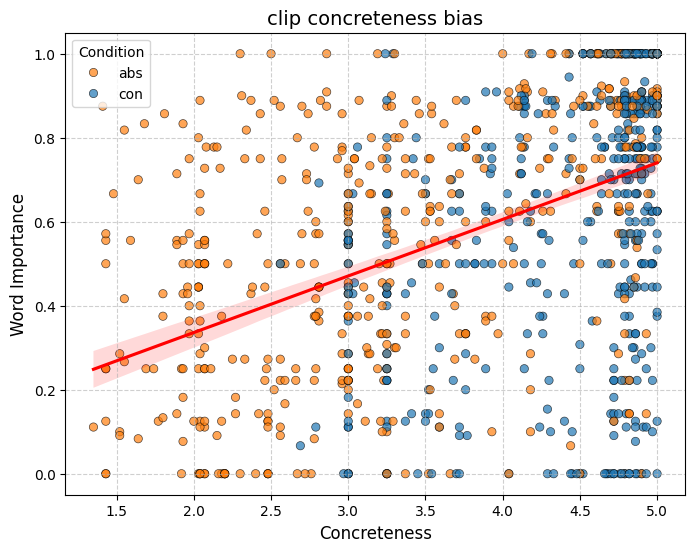

Slope: 0.0263, Intercept: 0.5240, R^2: 0.0093, p-value: 2.1422e-03


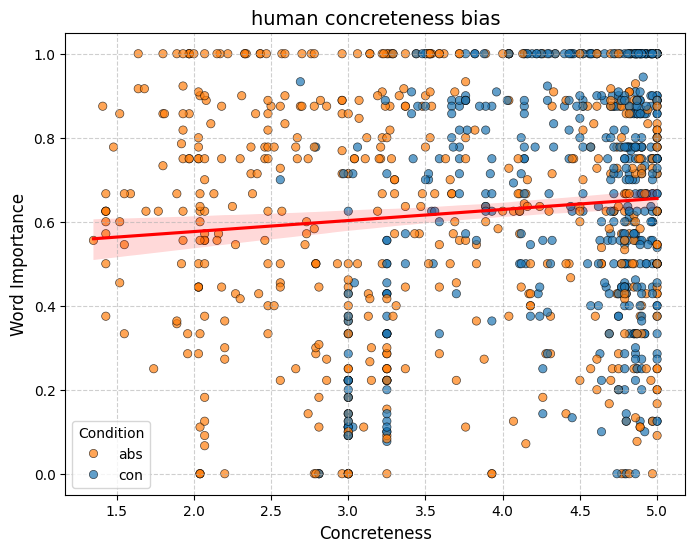

Slope: 0.0266, Intercept: 0.5223, R^2: 0.0097, p-value: 1.8081e-03


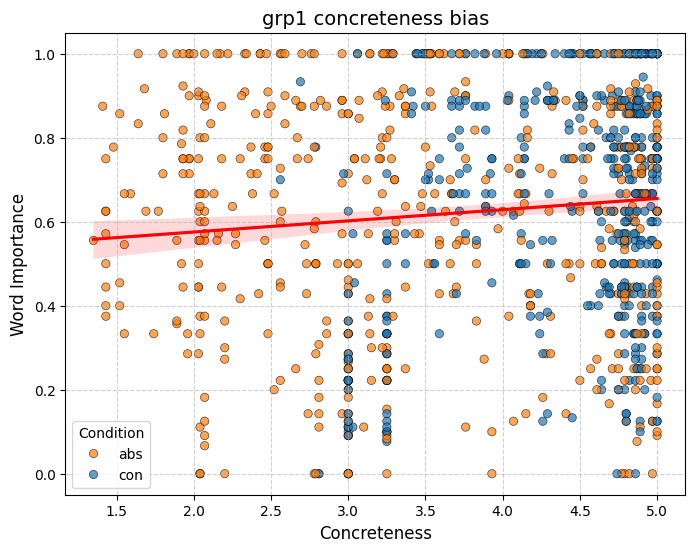

Slope: 0.0236, Intercept: 0.5262, R^2: 0.0072, p-value: 7.2058e-03


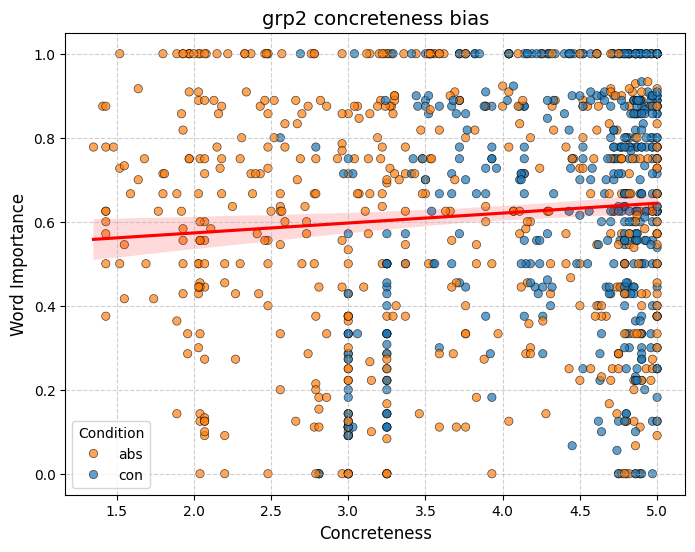

In [23]:
for grp in ['clip','human','grp1','grp2']:
    plot_data = all_words_df[all_words_df['concreteness'].notna()]
    linreg_scatter(plot_data,
                 x_attr='concreteness',
                 y_attr=f'{grp}_importance',
                 condition_attr='condition',
                 title=f'{grp} concreteness bias',
                 xlabel='Concreteness',
                 ylabel=f'Word Importance',
                 save_path=None)

In [24]:
verb_words_df = all_words_df[all_words_df['pos_tag'].str.startswith('VB')]
noun_words_df = all_words_df[all_words_df['pos_tag'].str.startswith('NN')]

for grp in ['clip','human','grp1','grp2']:
    t_stat, p_value = ttest_ind(noun_words_df[f'{grp}_importance'], verb_words_df[f'{grp}_importance'], equal_var=False)
    print(f"({grp}) T-statistic: {t_stat}, P-value: {p_value}")

(clip) T-statistic: 9.661288357867125, P-value: 1.2534794327015416e-19
(human) T-statistic: -1.7597542240780129, P-value: 0.07946396433676421
(grp1) T-statistic: -1.5289791794075311, P-value: 0.12731790089578002
(grp2) T-statistic: -1.4138589834343525, P-value: 0.15841516288145494


In [25]:
verb_words_df = all_words_df[all_words_df['pos_tag'].str.startswith('VB') & (all_words_df['concreteness'].notna())]
noun_words_df = all_words_df[all_words_df['pos_tag'].str.startswith('NN') & (all_words_df['concreteness'].notna())]

for grp in ['clip','human','grp1','grp2']:
    t_stat, p_value = ttest_ind(noun_words_df[f'{grp}_importance'], verb_words_df[f'{grp}_importance'], equal_var=False)
    print(f"({grp}) T-statistic: {t_stat}, P-value: {p_value}")

(clip) T-statistic: 6.820883984207017, P-value: 1.0436529399879398e-10
(human) T-statistic: -4.976237681903252, P-value: 1.3718372782390093e-06
(grp1) T-statistic: -4.688853923323544, P-value: 5.01655390093267e-06
(grp2) T-statistic: -3.5597233929747945, P-value: 0.0004653374685804015


In [26]:
verb_words_df = all_words_df[(all_words_df['pos_tag'].str.startswith('VB')) & (all_words_df['concreteness'].notna())]
noun_words_df = all_words_df[(all_words_df['pos_tag'].str.startswith('NN')) & (all_words_df['concreteness'].notna())]

t_stat, p_value = ttest_ind(noun_words_df['concreteness'], verb_words_df['concreteness'], equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 15.789777820039795, P-value: 1.7114909458155722e-34


Mixed effect model

In [27]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for _, info in all_words_df.iterrows():
    if np.isnan(info['concreteness']) or not (info['pos_tag'].startswith('VB') or info['pos_tag'].startswith('NN')):
        continue
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": info["trial_id"],
            "condition": info["condition"],
            "POS": 'VB' if info['pos_tag'].startswith('VB') else 'NN',
            "concreteness": info["concreteness"],
            "clip_importance": info["clip_importance"],
            "human_importance": info["human_importance"],
            "grp1_importance": info["grp1_importance"],
            "grp2_importance": info["grp2_importance"]
        }])
    ], ignore_index=True)

# Display the prepared long format DataFrame
long_format_data

,trial_id,condition,POS,concreteness,clip_importance,human_importance,grp1_importance,grp2_importance
0,matched_abs_COCO_val2014_000000057495.jpg,abs,NN,2.07,0.111111,0.555556,0.555556,0.444444
1,matched_abs_COCO_val2014_000000057495.jpg,abs,NN,4.52,1.000000,1.000000,0.888889,0.888889
2,matched_abs_COCO_val2014_000000057495.jpg,abs,VB,2.78,0.777778,0.000000,0.000000,0.111111
3,matched_con_COCO_val2014_000000057495.jpg,con,VB,4.04,0.000000,1.000000,1.000000,1.000000
4,matched_con_COCO_val2014_000000057495.jpg,con,NN,4.97,1.000000,0.600000,0.600000,0.600000
...,...,...,...,...,...,...,...,...
666,matched_con_COCO_val2014_000000098658.jpg,con,VB,3.96,0.909091,0.909091,1.000000,0.727273
667,matched_con_COCO_val2014_000000098658.jpg,con,NN,4.89,0.818182,0.545455,0.545455,0.363636
668,matched_con_COCO_val2014_000000098658.jpg,con,NN,4.22,0.454545,1.000000,0.909091,1.000000
669,matched_con_COCO_val2014_000000098658.jpg,con,NN,5.00,1.000000,0.727273,0.727273,0.909091


In [28]:
import pandas as pd
import statsmodels.formula.api as smf

for measurement in ['clip', 'human', 'grp1', 'grp2']:
    print(f"Mixed-Effect Model Analysis for {measurement}_importance:")
    model = smf.mixedlm(f"{measurement}_importance ~ POS * concreteness", long_format_data, groups="trial_id")
    result = model.fit()
    print(result.summary())

Mixed-Effect Model Analysis for clip_importance:


/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  clip_importance
No. Observations:   671      Method:              REML           
No. Groups:         160      Scale:               0.0836         
Min. group size:    2        Log-Likelihood:      -129.1943      
Max. group size:    9        Converged:           Yes            
Mean group size:    4.2                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.261    0.105  2.499 0.012  0.056  0.466
POS[T.VB]              -0.066    0.156 -0.421 0.674 -0.373  0.241
concreteness            0.097    0.023  4.240 0.000  0.052  0.141
POS[T.VB]:concreteness -0.004    0.040 -0.094 0.925 -0.083  0.075
trial_id Var            0.000    0.012                           

Mixed-Effect Model Anal

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  human_importance
No. Observations:  671      Method:              REML            
No. Groups:        160      Scale:               0.0664          
Min. group size:   2        Log-Likelihood:      -52.1518        
Max. group size:   9        Converged:           Yes             
Mean group size:   4.2                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.796    0.088  9.008 0.000  0.622  0.969
POS[T.VB]              -0.052    0.139 -0.373 0.709 -0.324  0.221
concreteness           -0.032    0.019 -1.697 0.090 -0.070  0.005
POS[T.VB]:concreteness  0.039    0.036  1.082 0.279 -0.031  0.109
trial_id Var            0.000                                    

Mixed-Effect Model Anal

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  grp1_importance
No. Observations:   671      Method:              REML           
No. Groups:         160      Scale:               0.0661         
Min. group size:    2        Log-Likelihood:      -50.8011       
Max. group size:    9        Converged:           Yes            
Mean group size:    4.2                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.819    0.089  9.237 0.000  0.645  0.993
POS[T.VB]              -0.089    0.139 -0.643 0.520 -0.361  0.183
concreteness           -0.038    0.019 -1.961 0.050 -0.075 -0.000
POS[T.VB]:concreteness  0.046    0.036  1.284 0.199 -0.024  0.116
trial_id Var            0.000                                    

Mixed-Effect Model Anal

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  grp2_importance
No. Observations:   671      Method:              REML           
No. Groups:         160      Scale:               0.0712         
Min. group size:    2        Log-Likelihood:      -75.4082       
Max. group size:    9        Converged:           Yes            
Mean group size:    4.2                                          
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.862    0.086 10.036 0.000  0.694  1.030
POS[T.VB]              -0.108    0.140 -0.767 0.443 -0.383  0.167
concreteness           -0.047    0.018 -2.579 0.010 -0.083 -0.011
POS[T.VB]:concreteness  0.042    0.036  1.160 0.246 -0.029  0.113
trial_id Var            0.000                                    



/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [29]:
# Prepare long format DataFrame for mixedlm analysis
long_format_data = pd.DataFrame()

for _, info in all_words_df.iterrows():
    if np.isnan(info['concreteness']) or not (info['pos_tag'].startswith('VB') or info['pos_tag'].startswith('NN')):
        continue
    long_format_data = pd.concat([
        long_format_data,
        pd.DataFrame([{
            "trial_id": info["trial_id"],
            "condition": info["condition"],
            "POS": 'VB' if info['pos_tag'].startswith('VB') else 'NN',
            "concreteness": info["concreteness"],
            "word_importance": info["grp1_importance"],
            "group": "grp1"
        },
        {
            "trial_id": info["trial_id"],
            "condition": info["condition"],
            "POS": 'VB' if info['pos_tag'].startswith('VB') else 'NN',
            "concreteness": info["concreteness"],
            "word_importance": info["grp2_importance"],
            "group": "grp2"
        }])
    ], ignore_index=True)

# Display the prepared long format DataFrame
model = smf.mixedlm("word_importance ~ POS * concreteness * group", long_format_data, groups="trial_id")
result = model.fit()
print(result.summary())

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       word_importance
No. Observations:       1342          Method:                   REML           
No. Groups:             160           Scale:                    0.0686         
Min. group size:        4             Log-Likelihood:           -126.6406      
Max. group size:        18            Converged:                Yes            
Mean group size:        8.4                                                    
-------------------------------------------------------------------------------
                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             0.819    0.092  8.950 0.000  0.640  0.999
POS[T.VB]                            -0.089    0.142 -0.629 0.529 -0.367  0.189
group[T.grp2]                         0.043    0.129  0.330 0

/home/jinhanz/miniconda3/envs/analysis/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
